<a href="https://colab.research.google.com/github/francescopassante/GETMeshClassifier/blob/main/GET/src/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%cd /content

/content


In [2]:
%rm -rf GETMeshClassificator/
!git clone https://github.com/francescopassante/GETMeshClassificator.git
%cd /content

Cloning into 'GETMeshClassificator'...
remote: Enumerating objects: 351, done.
remote: Counting objects: 100% (351/351), done.
remote: Compressing objects: 100% (217/217), done.
remote: Total 351 (delta 110), reused 277 (delta 71), pack-reused 0 (from 0)
Receiving objects: 100% (351/351), 300.78 KiB | 8.59 MiB/s, done.
Resolving deltas: 100% (110/110), done.
/content


In [3]:
# Download dataset with gdown:
!gdown 1e96CxX_JXAUGjYM1EOOtglIihpTFLN4J
!unzip -q SHREC11_200NEIGH.zip

Downloading...
From (original): https://drive.google.com/uc?id=1e96CxX_JXAUGjYM1EOOtglIihpTFLN4J
From (redirected): https://drive.google.com/uc?id=1e96CxX_JXAUGjYM1EOOtglIihpTFLN4J&confirm=t&uuid=f18e2a0f-0371-4816-86ef-558e16c7a3de
To: /content/SHREC11_200NEIGH.zip
100% 2.40G/2.40G [00:30<00:00, 78.6MB/s]


In [4]:
%cd GETMeshClassificator/GET/src

/content/GETMeshClassificator/GET/src


In [9]:
import GET
import GEUtils
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

train_loader, test_loader = GET.load_data(
        mesh_directory="../../../SHREC11_200NEIGH/processed/",
        labels_file="../../../SHREC11_200NEIGH/classes.txt",
        N=9,
        train_percent=0.7,
)
print(len(train_loader), len(test_loader))

414 178


In [14]:
def train(
    model,
    dataloader,
    optimizer,
    scheduler,
    criterion,
    device,
    epochs=1,
    accumulation_steps=16,
):
    model.train()
    loss_hist = []
    r2r = GEUtils.RegularToRegular(model.local_to_regular.N)
    r2r.A = r2r.A.to(device)

    for epoch in range(epochs):
        total_loss = 0.0

        # Start with zeroed gradients for the first accumulation block
        optimizer.zero_grad()

        for i, mesh in enumerate(tqdm(dataloader, desc=f"Epoch {epoch + 1}/{epochs}")):
            x = mesh["x"].to(device).squeeze(0)
            neighbors = mesh["neighbors"].to(device).squeeze(0)
            mask = mesh["mask"].to(device).squeeze(0)
            parallel_transport_angles = (
                mesh["parallel_transport_angles"].to(device).squeeze(0)
            )
            rel_pos_u = mesh["rel_pos"].to(device).squeeze(0)
            labels = mesh["label"].to(device).long().squeeze(0)

            parallel_transport_matrices = r2r.extended_regular_representation(
                parallel_transport_angles
            )

            for name, t in {
              "x": x,
              "neighbors": neighbors,
              "mask": mask,
              "ptm": parallel_transport_matrices,
              "rel_pos": rel_pos_u,
              }.items():
                if not torch.isfinite(t).all():
                    print("Bad tensor:", name, "mesh:", mesh.get("filenumber", "unknown"))

            # Forward
            outputs = model(x, neighbors, mask, parallel_transport_matrices, rel_pos_u)
            if not torch.isfinite(outputs).all():
              print("Non-finite outputs on mesh:", mesh.get("filenumber", "unknown"))

            # Print the index of dimension with max output
            # print("mesh file: ", mesh["filenumber"])
            # print("predicted label: ", torch.argmax(outputs).item())
            # print("True label: ", labels.item())
            raw_loss = criterion(outputs.unsqueeze(0), labels.unsqueeze(0))

            if not torch.isfinite(raw_loss):
              print("Non-finite loss on mesh:", mesh.get("filenumber", "unknown"))

            # Scale the loss for gradient accumulation
            scaled_loss = raw_loss / accumulation_steps
            scaled_loss.backward()

            # Accumulate the raw (unscaled) loss for logging
            total_loss += raw_loss.item()

            # Step and zero gradients at the accumulation boundary (or final batch)
            if (i + 1) % accumulation_steps == 0 or (i + 1) == len(dataloader):
                #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()

        # Average epoch loss (uses unscaled batch losses)
        epoch_loss = total_loss / len(dataloader)
        print("epoch_loss: ", epoch_loss)
        loss_hist.append(epoch_loss)
        scheduler.step()
        # Save checkpoint with meaningful loss value (epoch average)
        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss": epoch_loss,
        }
        save_path = f"checkpoint{epoch}.pth"
        torch.save(checkpoint, save_path)
        print(f"Saved checkpoint to {save_path} (epoch_loss={epoch_loss:.6f})")

    return loss_hist

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = GET.GETClassifier(N=9, channels=12, heads = 2, out_classes=30).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.1)
num_params = sum(p.numel() for p in model.parameters())
print(f"Model has {num_params} parameters")

Model has 9114 parameters


In [16]:
train(model,
    train_loader,
    optimizer,
    scheduler,
    criterion,
    device,
    epochs=70,
    accumulation_steps=4)

Epoch 1/70: 100%|██████████| 414/414 [04:22<00:00,  1.58it/s]


epoch_loss:  3.5104828082420974
Saved checkpoint to checkpoint0.pth (epoch_loss=3.510483)


Epoch 2/70: 100%|██████████| 414/414 [04:22<00:00,  1.57it/s]


epoch_loss:  3.413309910447125
Saved checkpoint to checkpoint1.pth (epoch_loss=3.413310)


Epoch 3/70: 100%|██████████| 414/414 [04:23<00:00,  1.57it/s]


...

epoch_loss:  0.7883099301229315
Saved checkpoint to checkpoint28.pth (epoch_loss=0.788310)


Epoch 30/70: 100%|██████████| 414/414 [04:22<00:00,  1.57it/s]


epoch_loss:  0.7345892339182094
Saved checkpoint to checkpoint29.pth (epoch_loss=0.734589)


Epoch 31/70:  13%|█▎        | 54/414 [00:34<03:51,  1.56it/s]


KeyboardInterrupt: 

In [ ]:
# Compute validation score history, loading each epoch from checkpoint{epoch}.pth:

### Validation Setup

First, I'll define a function to evaluate the model on a given DataLoader. Then, I'll create a validation DataLoader using 20% of the `test_loader`'s dataset.

In [22]:
def validate(model, dataloader, criterion, device):
    model.eval() # Set the model to evaluation mode
    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    r2r = GEUtils.RegularToRegular(model.local_to_regular.N)
    r2r.A = r2r.A.to(device)

    with torch.no_grad(): # Disable gradient calculation during validation
        for mesh in tqdm(dataloader, desc="Validating"):
            x = mesh["x"].to(device).squeeze(0)
            neighbors = mesh["neighbors"].to(device).squeeze(0)
            mask = mesh["mask"].to(device).squeeze(0)
            parallel_transport_angles = (
                mesh["parallel_transport_angles"].to(device).squeeze(0)
            )
            rel_pos_u = mesh["rel_pos"].to(device).squeeze(0)
            labels = mesh["label"].to(device).long().squeeze(0)

            parallel_transport_matrices = r2r.extended_regular_representation(
                parallel_transport_angles
            )

            outputs = model(x, neighbors, mask, parallel_transport_matrices, rel_pos_u)
            loss = criterion(outputs.unsqueeze(0), labels.unsqueeze(0))
            total_loss += loss.item()

            # Corrected: outputs is a 1D tensor [num_classes], labels is a 0D tensor (scalar)
            _, predicted = torch.max(outputs.data, 0) # Get the index of the max value along the only dimension
            total_samples += 1 # Increment by 1 for each sample
            correct_predictions += (predicted == labels).item() # Compare scalars and convert boolean to 0 or 1

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct_predictions / total_samples
    return avg_loss, accuracy


# Create a validation set from a subset of the test_loader
validation_split_ratio = 0.3
num_test_samples = len(test_loader.dataset)
num_validation_samples = int(validation_split_ratio * num_test_samples)
print("validation size: ", num_validation_samples)

# Create a random subset of indices for validation
indices = list(range(num_test_samples))
import random
random.shuffle(indices)
validation_indices = indices[:num_validation_samples]

# Create a Subset dataset for validation
validation_dataset = torch.utils.data.Subset(test_loader.dataset, validation_indices)
test_dataset = torch.utils.data.Subset(test_loader.dataset, indices[num_validation_samples:])

# Create a DataLoader for the validation set
validation_loader = torch.utils.data.DataLoader(
    validation_dataset,
    batch_size=1, # Assuming batch_size 1 like in your train function
    shuffle=False, # No need to shuffle validation set
    num_workers=2 # Use appropriate num_workers
)

print(f"Validation set created with {len(validation_loader)} samples (20% of test_loader).")

validation size:  53
Validation set created with 53 samples (20% of test_loader).


### Loading Checkpoints and Running Validation

Now, I'll load each saved checkpoint, run the validation function, and store the validation losses and accuracies.

In [23]:
validation_loss_history = []
validation_accuracy_history = []

# Assuming `epochs` from train function is the total number of epochs
# and checkpoints are named checkpoint0.pth, checkpoint1.pth, ..., checkpoint(epochs-1).pth
for epoch in range(70):
    checkpoint_path = f"checkpoint{epoch}.pth"
    try:
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        # It's good practice to also load scheduler state if you plan to continue training
        # scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

        epoch_validation_loss, epoch_validation_accuracy = validate(model, validation_loader, criterion, device)
        validation_loss_history.append(epoch_validation_loss)
        validation_accuracy_history.append(epoch_validation_accuracy)

        print(f"Epoch {epoch}: Validation Loss = {epoch_validation_loss:.4f}, Validation Accuracy = {epoch_validation_accuracy:.2f}%")

    except FileNotFoundError:
        print(f"Checkpoint {checkpoint_path} not found. Skipping.")

print("Validation history:")
print(f"Losses: {validation_loss_history}")
print(f"Accuracies: {validation_accuracy_history}")

Validating: 100%|██████████| 53/53 [00:09<00:00,  5.58it/s]


Epoch 0: Validation Loss = 3.4596, Validation Accuracy = 0.00%


Validating: 100%|██████████| 53/53 [00:09<00:00,  5.47it/s]


Epoch 1: Validation Loss = 3.4221, Validation Accuracy = 3.77%


Validating: 100%|██████████| 53/53 [00:10<00:00,  5.26it/s]


...

Epoch 27: Validation Loss = 1.0248, Validation Accuracy = 60.38%


Validating: 100%|██████████| 53/53 [00:09<00:00,  5.51it/s]


Epoch 28: Validation Loss = 0.9045, Validation Accuracy = 56.60%


Validating: 100%|██████████| 53/53 [00:09<00:00,  5.49it/s]

Epoch 29: Validation Loss = 0.7546, Validation Accuracy = 77.36%
Checkpoint checkpoint30.pth not found. Skipping.
Checkpoint checkpoint31.pth not found. Skipping.
Checkpoint checkpoint32.pth not found. Skipping.
Checkpoint checkpoint33.pth not found. Skipping.
Checkpoint checkpoint34.pth not found. Skipping.
Checkpoint checkpoint35.pth not found. Skipping.
Checkpoint checkpoint36.pth not found. Skipping.
Checkpoint checkpoint37.pth not found. Skipping.
Checkpoint checkpoint38.pth not found. Skipping.
Checkpoint checkpoint39.pth not found. Skipping.
Checkpoint checkpoint40.pth not found. Skipping.
Checkpoint checkpoint41.pth not found. Skipping.
Checkpoint checkpoint42.pth not found. Skipping.
Checkpoint checkpoint43.pth not found. Skipping.
Checkpoint checkpoint44.pth not found. Skipping.
Checkpoint checkpoint45.pth not found. Skipping.
Checkpoint checkpoint46.pth not found. Skipping.
Checkpoint checkpoint47.pth not found. Skipping.
Checkpoint checkpoint48.pth not found. Skipping.
Chec

### Plotting Training and Validation Loss

To visualize the training progress and validation performance over epochs, I'll now plot both the training loss (from the checkpoints) and the newly computed validation loss.

Checkpoint checkpoint30.pth not found. Cannot retrieve training loss.
Checkpoint checkpoint31.pth not found. Cannot retrieve training loss.
Checkpoint checkpoint32.pth not found. Cannot retrieve training loss.
Checkpoint checkpoint33.pth not found. Cannot retrieve training loss.
Checkpoint checkpoint34.pth not found. Cannot retrieve training loss.
Checkpoint checkpoint35.pth not found. Cannot retrieve training loss.
Checkpoint checkpoint36.pth not found. Cannot retrieve training loss.
Checkpoint checkpoint37.pth not found. Cannot retrieve training loss.
Checkpoint checkpoint38.pth not found. Cannot retrieve training loss.
Checkpoint checkpoint39.pth not found. Cannot retrieve training loss.
Checkpoint checkpoint40.pth not found. Cannot retrieve training loss.
Checkpoint checkpoint41.pth not found. Cannot retrieve training loss.
Checkpoint checkpoint42.pth not found. Cannot retrieve training loss.
Checkpoint checkpoint43.pth not found. Cannot retrieve training loss.
Checkpoint checkpoin

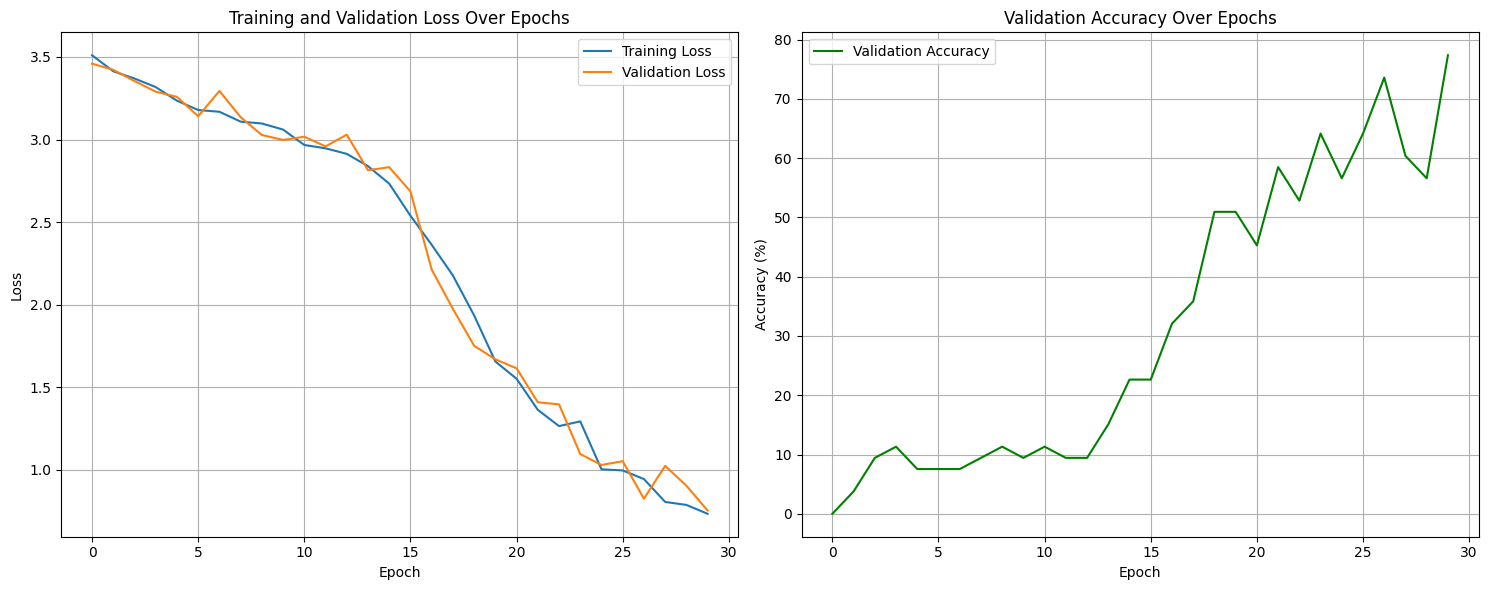

In [25]:
import matplotlib.pyplot as plt

training_loss_from_checkpoints = []
for epoch in range(70):
    checkpoint_path = f"checkpoint{epoch}.pth"
    try:
        checkpoint = torch.load(checkpoint_path)
        training_loss_from_checkpoints.append(checkpoint["loss"])
    except FileNotFoundError:
        print(f"Checkpoint {checkpoint_path} not found. Cannot retrieve training loss.")
        training_loss_from_checkpoints.append(None) # Add None for missing checkpoints

# Filter out None values if some checkpoints were missing
training_loss_from_checkpoints = [loss for loss in training_loss_from_checkpoints if loss is not None]

# Create two subplots for loss and accuracy
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Training and Validation Loss
axes[0].plot(range(len(training_loss_from_checkpoints)), training_loss_from_checkpoints, label='Training Loss')
axes[0].plot(range(len(validation_loss_history)), validation_loss_history, label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss Over Epochs')
axes[0].legend()
axes[0].grid(True)

# Plot Validation Accuracy
axes[1].plot(range(len(validation_accuracy_history)), validation_accuracy_history, label='Validation Accuracy', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Validation Accuracy Over Epochs')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Evaluating the Best Model on the Test Set

Now, I'll select the model checkpoint that yielded the lowest validation loss, load it, and compute its accuracy on the held-out test set.

In [26]:
# Find the epoch with the best validation accuracy (and lowest loss in case of ties)
if validation_accuracy_history:
    max_val_accuracy = max(validation_accuracy_history)
    best_epochs_by_accuracy = [
        i for i, acc in enumerate(validation_accuracy_history) if acc == max_val_accuracy
    ]

    # Among those with max accuracy, find the one with the minimum loss
    best_epoch_candidate = -1
    min_loss_at_max_acc = float('inf')

    for epoch_idx in best_epochs_by_accuracy:
        if validation_loss_history[epoch_idx] < min_loss_at_max_acc:
            min_loss_at_max_acc = validation_loss_history[epoch_idx]
            best_epoch_candidate = epoch_idx

    best_epoch = best_epoch_candidate

    print(f"Best model found at epoch {best_epoch} with validation accuracy: {max_val_accuracy:.2f}% and validation loss: {validation_loss_history[best_epoch]:.4f}")

    # Load the best model checkpoint
    best_checkpoint_path = f"checkpoint{best_epoch}.pth"
    try:
        best_checkpoint = torch.load(best_checkpoint_path)
        model.load_state_dict(best_checkpoint["model_state_dict"])
        print(f"Loaded model from {best_checkpoint_path}")

        # Create a DataLoader for the test set (remaining data after validation split)
        test_loader_final = torch.utils.data.DataLoader(
            test_dataset,
            batch_size=1, # Assuming batch_size 1
            shuffle=False,
            num_workers=2
        )

        # Evaluate on the test set
        test_loss, test_accuracy = validate(model, test_loader_final, criterion, device)
        print(f"Test Loss = {test_loss:.4f}, Test Accuracy = {test_accuracy:.2f}%")

    except FileNotFoundError:
        print(f"Error: Best checkpoint {best_checkpoint_path} not found.")
else:
    print("No validation history available to determine the best model.")

Best model found at epoch 29 with validation accuracy: 77.36% and validation loss: 0.7546
Loaded model from checkpoint29.pth


Validating: 100%|██████████| 125/125 [00:22<00:00,  5.49it/s]

Test Loss = 0.7355, Test Accuracy = 82.40%
